# Classification Tree

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [16]:
df = pd.read_csv('weather_forecast.csv')

In [17]:
df

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [20]:
# sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)[source]

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [21]:
X = df.iloc[:,:-1]
y = df['Play']


In [25]:
from sklearn.preprocessing import LabelEncoder

# Apply encoding to each categorical column
le = LabelEncoder()

X['Outlook'] = le.fit_transform(X['Outlook'])   # Sunny, Overcast, Rain → 0,1,2
X['Temperature'] = le.fit_transform(X['Temperature'])
X['Humidity'] = le.fit_transform(X['Humidity'])
X['Windy'] = le.fit_transform(X['Windy'])

/tmp/ipykernel_7783/3714606134.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Outlook'] = le.fit_transform(X['Outlook'])   # Sunny, Overcast, Rain → 0,1,2
/tmp/ipykernel_7783/3714606134.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Temperature'] = le.fit_transform(X['Temperature'])
/tmp/ipykernel_7783/3714606134.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [26]:
X

,Outlook,Temperature,Humidity,Windy
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [29]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


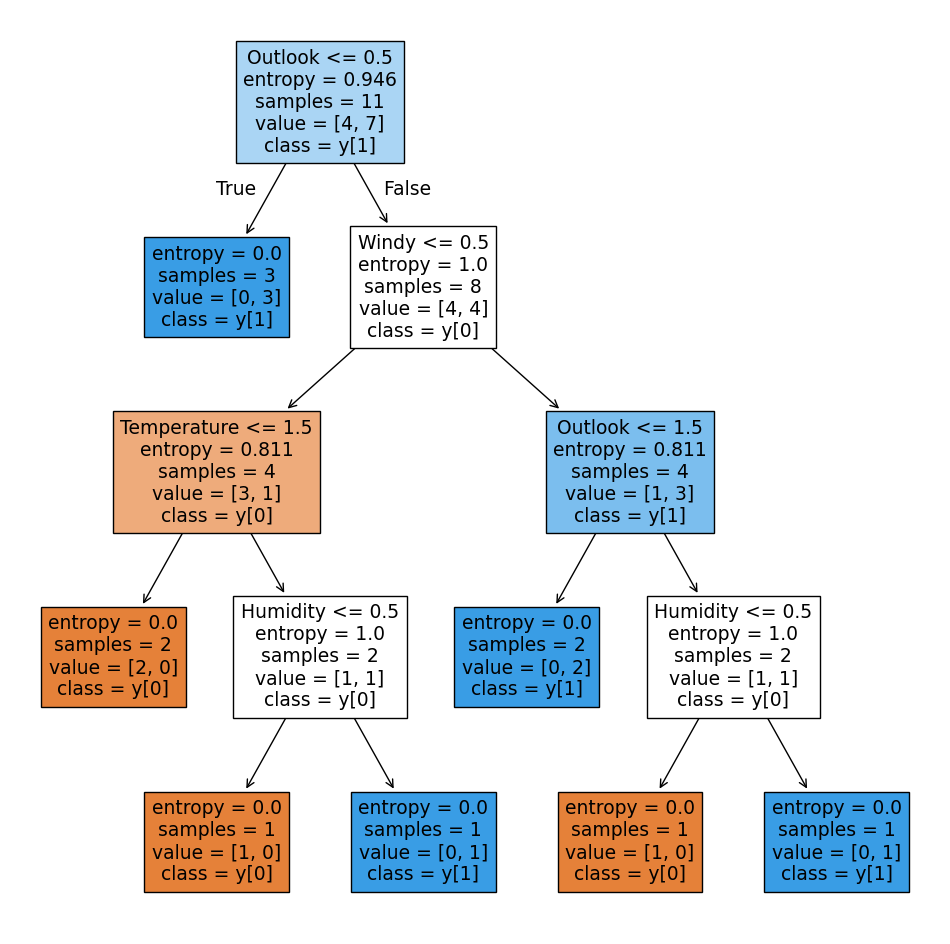

In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=True
)
plt.show()

## Regression Tree

In [33]:
df2 = pd.read_csv('Regression_data.csv')

In [34]:
df2

,hours,marks
0,1.0,20
1,2.0,30
2,3.0,40
3,2.5,35
4,1.5,27
5,1.2,29
6,1.1,31
7,1.7,35
8,2.2,21
9,2.4,40


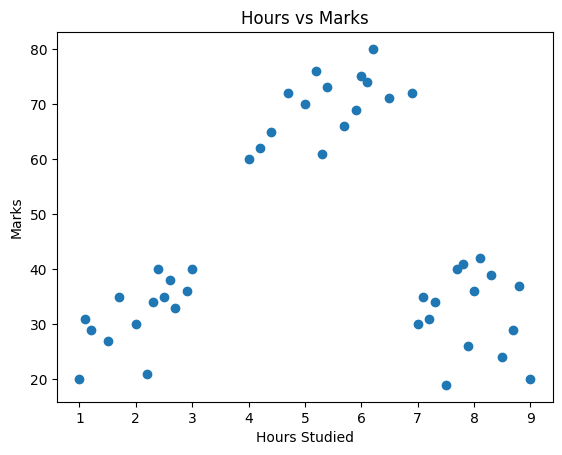

In [36]:
import matplotlib.pyplot as plt


plt.scatter(df2['hours'], df2['marks'])

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")

plt.show()

In [39]:
X = df2[["hours"]]
y = df2["marks"]

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.tree import DecisionTreeRegressor

model_reg = DecisionTreeRegressor()

In [41]:
model_reg.fit(X_train,y_train)

DecisionTreeRegressor()

In [42]:
y_pred = model_reg.predict(X_test)

if max_depth is not fixed then:

MSE: 90.77777777777777
R2 Score: 0.7649296675191816


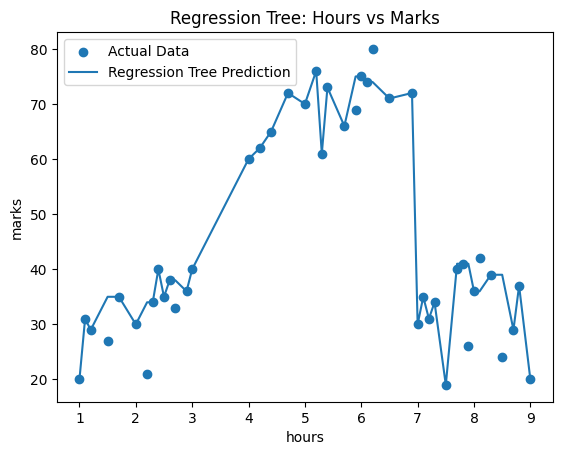

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Smooth prediction curve
X_range = pd.DataFrame({"hours": sorted(df2["hours"])})
y_range_pred = model_reg.predict(X_range)

plt.plot(X_range, y_range_pred, label="Regression Tree Prediction")
plt.xlabel("hours")
plt.ylabel("marks")
plt.title("Regression Tree: Hours vs Marks")
plt.legend()

max_depth set to 2

MSE: 64.22483011937557
R2 Score: 0.8336888989875504


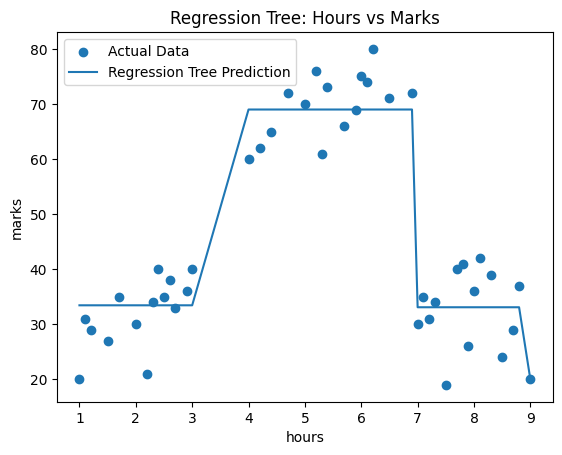

In [51]:
model_reg = DecisionTreeRegressor(max_depth=2)
model_reg.fit(X_train,y_train)

y_pred = model_reg.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot actual data
plt.scatter(X, y, label="Actual Data")

# Smooth prediction curve
X_range = pd.DataFrame({"hours": sorted(df2["hours"])})
y_range_pred = model_reg.predict(X_range)

plt.plot(X_range, y_range_pred, label="Regression Tree Prediction")
plt.xlabel("hours")
plt.ylabel("marks")
plt.title("Regression Tree: Hours vs Marks")
plt.legend()